In [47]:
# Step 1 - Read the dataset

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os

import cv2 as cv

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import warnings
warnings.filterwarnings("ignore")

In [48]:
train_dir = 'E:\\UCT Training AIMLDS\\GENAI_IITG_6Months\\brain_tumor_dataset\\Training'
test_dir = 'E:\\UCT Training AIMLDS\\GENAI_IITG_6Months\\brain_tumor_dataset\\Testing'

In [49]:
# Define a List for training and testing
X_train_list = [] 
y_train_list = []

In [50]:
# Class names

labels = os.listdir(train_dir)
print(labels)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [51]:
os.listdir(test_dir)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

In [52]:
# Define the image size and batch size

img_size = (150,150)
batch_size = 32

In [53]:
# Print the data path

for i in labels:
    path = os.path.join(train_dir, i)
    print(path)
 
print('-'*80)   
for i in labels:
    path = os.path.join(test_dir, i)
    print(path)

E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\glioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\meningioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\no_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\pituitary_tumor
--------------------------------------------------------------------------------
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\glioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\meningioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\no_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\pituitary_tumor


In [54]:
# Load the training data

for i in labels:
    path = os.path.join(train_dir, i)
    
    for j in os.listdir(path):
        image = cv.imread(os.path.join(path,j))
        image = cv.resize(image, img_size)
        X_train_list.append(image)
        y_train_list.append(i)
        
        
for i in labels:
    path = os.path.join(test_dir, i)
    
    for j in os.listdir(path):
        image = cv.imread(os.path.join(path, j))
        image = cv.resize(image, img_size)
        X_train_list.append(image)
        y_train_list.append(i)

In [55]:
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

In [56]:
len(X_train)

3264

In [57]:
X_train

array([[[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        ...,

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]]],


       [[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0, 

In [58]:
len(y_train)

3264

In [59]:
X_train.min()

np.uint8(0)

In [60]:
X_train.max()

np.uint8(255)

In [61]:
# Shuffle the data

from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train, random_state=101)
X_train.shape, y_train.shape

((3264, 150, 150, 3), (3264,))

In [62]:
X_train[0]

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       ...,

       [[54, 54, 54],
        [70, 70, 70],
        [69, 69, 69],
        ...,
        [ 1,  1,  1],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[42, 42, 42],
        [64, 64, 64],
        [69, 69, 69],
        ...,
        [ 1,  1,  1],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[28, 28, 28],
        [55, 55, 55],
        [64, 64, 64],
        ...,
        [ 1,  1,  1],
        [ 0,  0,  0],
        [ 0,  0,  0]]], shape=(150, 150, 3), dtype=uint8)

In [63]:
y_train[0]

np.str_('no_tumor')

In [64]:
y_train_index = []
for i in y_train:
    y_train_index.append(labels.index(i))
y_train = y_train_index
y_train[0]

2

In [65]:
my_list = ['a', 'b', 'c']
my_list.index('b')

1

In [66]:
X_train.dtype

dtype('uint8')

In [67]:
X_train  = np.array(X_train.astype('float32')) / 255.0

In [68]:
X_train[0]

array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.21176471, 0.21176471, 0.21176471],
        [0.27450982, 0.27450982, 0.27450982],
        [0.27058825, 0

In [69]:
y_train = np.array(y_train)

In [70]:
print(type(X_train), X_train.shape, X_train.dtype)

<class 'numpy.ndarray'> (3264, 150, 150, 3) float32


In [71]:
print(type(y_train), y_train.shape, y_train.dtype)

<class 'numpy.ndarray'> (3264,) int64


In [72]:
# Model V1

model_v1 = Sequential()

# Add the first convolutional layer
model_v1.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (img_size[0], img_size[1], 3)))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add the second convolutional layer
model_v1.add(Conv2D(64, (3, 3), activation = 'relu'))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add the third convolutional layer
model_v1.add(Conv2D(128, (3, 3), activation = 'relu'))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add the fourth convolutional layer
model_v1.add(Conv2D(256, (3, 3), activation = 'relu'))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add fully connected layers
model_v1.add(Flatten())

model_v1.add(Dense(512, activation = 'relu'))
model_v1.add(Dropout(0.3))
model_v1.add(Dense(256, activation = 'relu'))
model_v1.add(Dropout(0.5))
model_v1.add(Dense(4, activation = 'softmax'))

model_v1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,945,732 (26.50 MB)

 Trainable params: 6,944,772 (26.49 MB)

 Non-trainable params: 960 (3.75 KB)

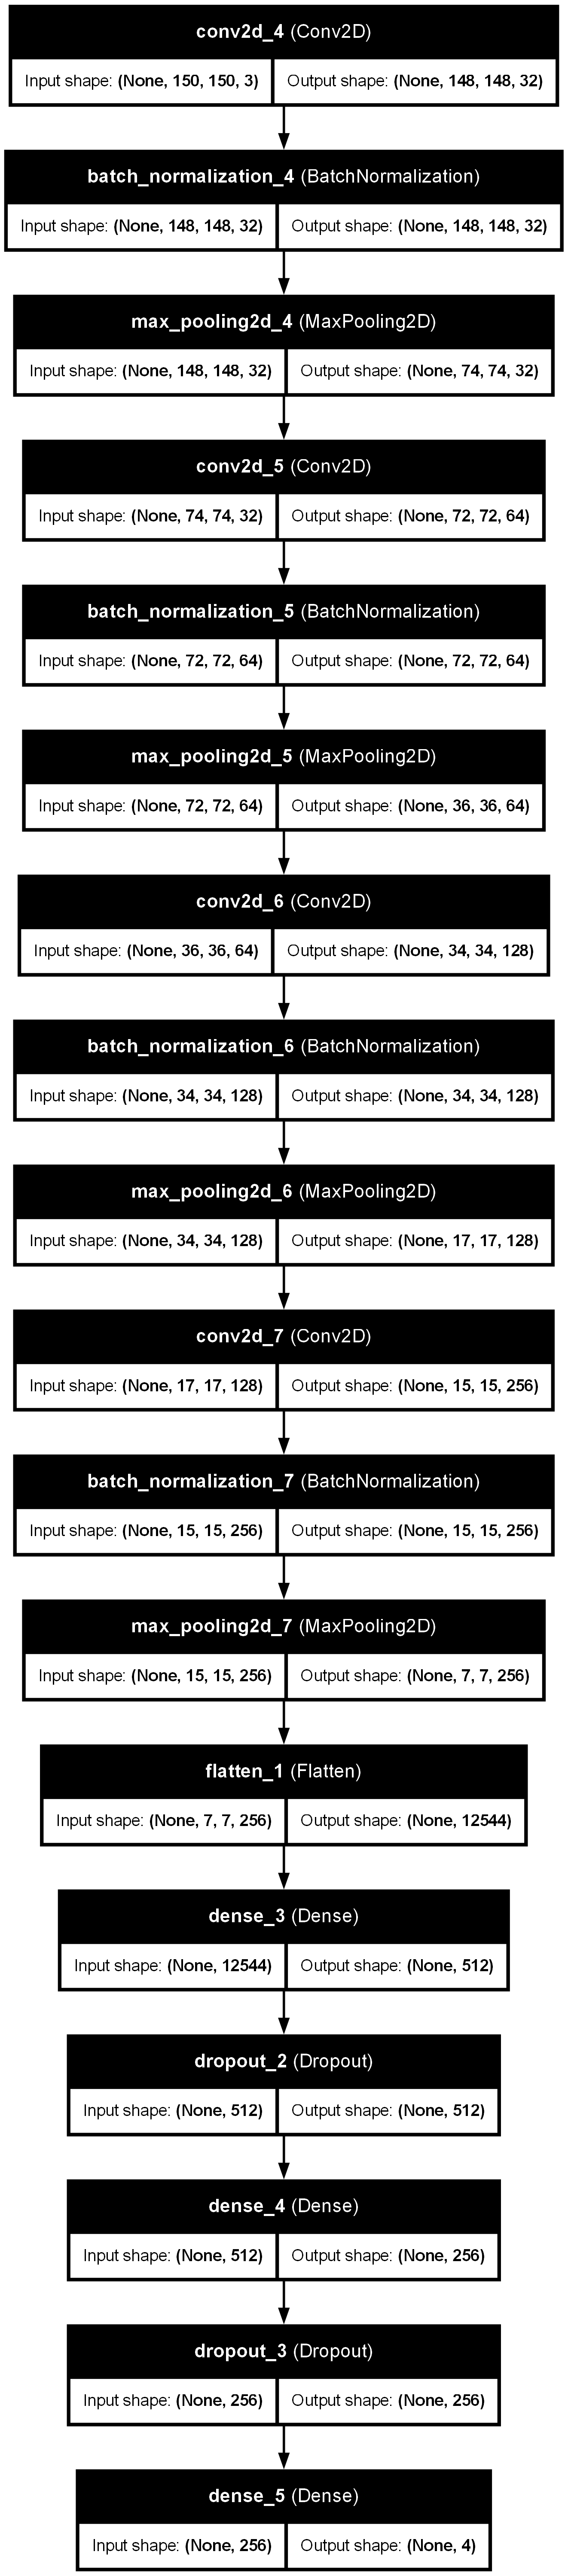

In [73]:
from tensorflow.keras.utils import plot_model
plot_model(model_v1, to_file='model_v1.png', show_shapes=True, show_layer_names=True)

In [74]:
from tensorflow.keras.optimizers import Adam

adam_optimizer = Adam(learning_rate=0.0001)

In [75]:
# Compile the model
model_v1.compile(optimizer = adam_optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2,random_state=101)
len(X_train),len(X_test),len(y_train),len(y_test)

(2611, 653, 2611, 653)

In [77]:
X_train.shape, y_train.shape

((2611, 150, 150, 3), (2611,))

In [78]:
y_train

array([2, 0, 2, ..., 1, 3, 1], shape=(2611,))

In [79]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=4)

In [81]:
# Train the model
history_v1 = model_v1.fit(X_train, y_train, epochs = 20, batch_size = batch_size, validation_data = (X_test, y_test), verbose = 1)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 650ms/step - accuracy: 0.7036 - loss: 0.7816 - val_accuracy: 0.1669 - val_loss: 2.9325
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 669ms/step - accuracy: 0.7476 - loss: 0.6349 - val_accuracy: 0.1669 - val_loss: 3.6968
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 58s 703ms/step - accuracy: 0.8154 - loss: 0.4978 - val_accuracy: 0.1945 - val_loss: 2.4937
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 675ms/step - accuracy: 0.8606 - loss: 0.3780 - val_accuracy: 0.3476 - val_loss: 2.2057
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 57s 697ms/step - accuracy: 0.8901 - loss: 0.2836 - val_accuracy: 0.8224 - val_loss: 0.4862
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 678ms/step - accuracy: 0.9123 - loss: 0.2450 - val_accuracy: 0.8744 - val_loss: 0.3338
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 57s 692ms/step - accuracy: 0.9265 - loss: 0.2076 - val_accuracy: 0.8806 - val_loss: 0.3548
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 54s 660ms/step - accuracy: 0.9590 - loss: 0.1294 - val_accu

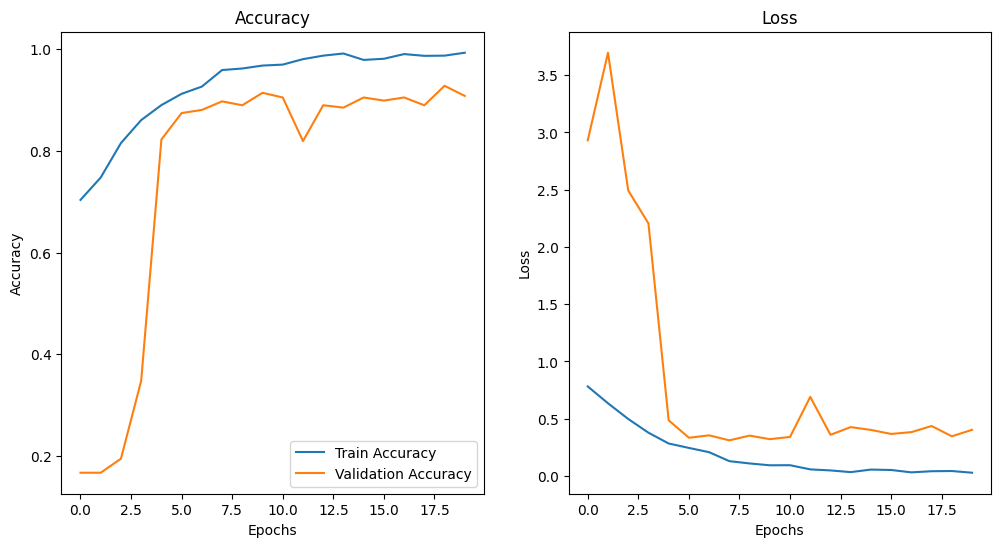

In [82]:
# Vizualizing the model performance

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_v1.history['accuracy'], label='Train Accuracy')
plt.plot(history_v1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')

plt.show()

In [83]:
y_pred = model_v1.predict(X_test)
y_pred

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step


array([[1.2576184e-04, 2.5372970e-04, 5.5730590e-05, 9.9956483e-01],
       [3.8383590e-05, 1.8716231e-05, 9.9994135e-01, 1.5797357e-06],
       [9.9938893e-01, 6.0918799e-04, 3.6660947e-07, 1.5513652e-06],
       ...,
       [1.9967979e-07, 2.2805420e-06, 2.2721224e-07, 9.9999726e-01],
       [9.9999762e-01, 2.3562945e-06, 2.9781424e-09, 5.5892091e-08],
       [6.8700210e-09, 3.1267272e-10, 1.4047960e-10, 1.0000000e+00]],
      shape=(653, 4), dtype=float32)

In [84]:
y_pred_class = np.argmax(y_pred, axis=1)

In [85]:
y_pred_class

array([3, 2, 0, 1, 3, 0, 2, 3, 1, 1, 2, 0, 0, 1, 1, 3, 3, 2, 3, 1, 3, 0,
       1, 1, 1, 3, 1, 3, 3, 1, 1, 3, 0, 1, 3, 2, 3, 2, 0, 2, 2, 0, 3, 1,
       1, 3, 0, 1, 3, 1, 2, 1, 3, 3, 1, 3, 0, 3, 1, 0, 1, 1, 1, 0, 3, 3,
       3, 0, 2, 0, 0, 0, 3, 1, 0, 2, 0, 2, 2, 1, 1, 0, 3, 3, 0, 0, 1, 1,
       2, 1, 1, 3, 1, 1, 0, 1, 0, 2, 3, 1, 1, 1, 2, 2, 3, 3, 3, 0, 0, 2,
       1, 0, 3, 0, 3, 0, 3, 3, 2, 1, 0, 1, 3, 0, 3, 3, 0, 3, 3, 0, 3, 1,
       1, 3, 2, 1, 1, 3, 1, 1, 1, 1, 2, 0, 1, 1, 0, 2, 2, 2, 3, 1, 1, 3,
       1, 3, 1, 1, 2, 1, 3, 1, 1, 1, 1, 0, 0, 1, 0, 1, 2, 3, 3, 1, 1, 1,
       1, 0, 3, 0, 3, 0, 1, 0, 3, 2, 1, 1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 1,
       3, 2, 3, 0, 3, 1, 2, 3, 2, 1, 1, 2, 1, 1, 1, 0, 0, 3, 0, 0, 3, 0,
       2, 1, 3, 1, 3, 0, 3, 1, 3, 2, 0, 0, 3, 0, 0, 2, 3, 3, 0, 0, 3, 0,
       1, 1, 0, 0, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 3, 1, 3, 3, 0, 3, 3, 1,
       0, 0, 0, 1, 1, 0, 0, 3, 3, 3, 0, 3, 1, 1, 0, 1, 2, 1, 3, 3, 1, 1,
       0, 1, 1, 0, 2, 1, 1, 3, 3, 2, 3, 0, 0, 1, 0,

In [86]:
y_true_classes = np.argmax(y_test, axis=1)

In [87]:
# Confusion Matrix

cm = confusion_matrix(y_true_classes, y_pred_class)
print("Confusion Matric:\n", cm)

Confusion Matric:
 [[145  20   3   0]
 [  4 188   0   8]
 [  5  16  88   0]
 [  0   4   0 172]]


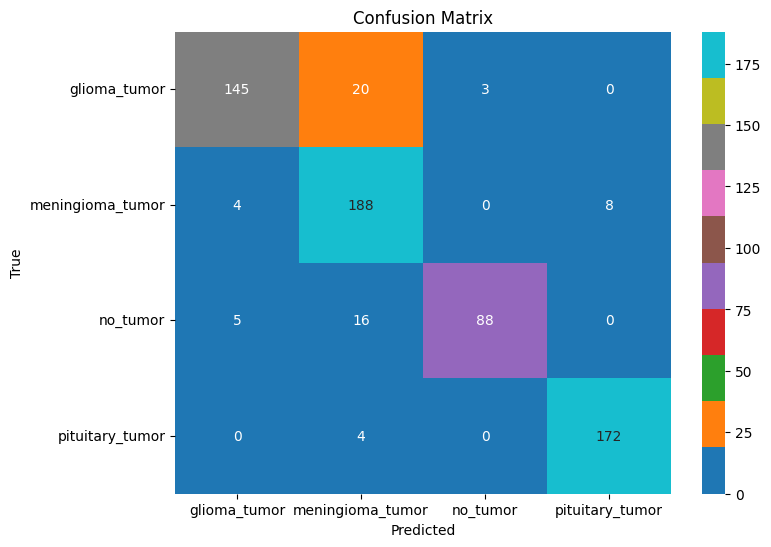

In [88]:
# Confusion Matrix with heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='tab10', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [89]:
print("Classification Report:\n", classification_report(y_true_classes, y_pred_class, target_names=labels))

Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       0.94      0.86      0.90       168
meningioma_tumor       0.82      0.94      0.88       200
        no_tumor       0.97      0.81      0.88       109
 pituitary_tumor       0.96      0.98      0.97       176

        accuracy                           0.91       653
       macro avg       0.92      0.90      0.91       653
    weighted avg       0.91      0.91      0.91       653



##### Regularized Model

From the accuracy plot, it is clearly visible that training could be stopped earlier for better performance.

So, model with **Early Stopping** 

In [90]:
early_stop = EarlyStopping(monitor="val_loss",
    min_delta=0.01,
    patience=5,
    verbose=1,
    restore_best_weights=False,
)

In [91]:
cp = ModelCheckpoint("best_model_v1.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

In [92]:
history_v2 = model_v1.fit(X_train, y_train, epochs=25, batch_size=batch_size, validation_data=(X_test, y_test), verbose=1,
                          callbacks=[early_stop, cp])

Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9933 - loss: 0.0339
Epoch 1: val_loss improved from None to 0.46136, saving model to best_model_v1.h5



Epoch 1: finished saving model to best_model_v1.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 675ms/step - accuracy: 0.9916 - loss: 0.0321 - val_accuracy: 0.9005 - val_loss: 0.4614
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.9923 - loss: 0.0243
Epoch 2: val_loss did not improve from 0.46136
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 674ms/step - accuracy: 0.9923 - loss: 0.0270 - val_accuracy: 0.8806 - val_loss: 0.4700
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.9907 - loss: 0.0391
Epoch 3: val_loss improved from 0.46136 to 0.44838, saving model to best_model_v1.h5



Epoch 3: finished saving model to best_model_v1.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 685ms/step - accuracy: 0.9893 - loss: 0.0411 - val_accuracy: 0.9005 - val_loss: 0.4484
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.9846 - loss: 0.0452
Epoch 4: val_loss did not improve from 0.44838
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 675ms/step - accuracy: 0.9824 - loss: 0.0566 - val_accuracy: 0.8897 - val_loss: 0.4888
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9833 - loss: 0.0431
Epoch 5: val_loss improved from 0.44838 to 0.42565, saving model to best_model_v1.h5



Epoch 5: finished saving model to best_model_v1.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 54s 663ms/step - accuracy: 0.9866 - loss: 0.0421 - val_accuracy: 0.9020 - val_loss: 0.4256
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9839 - loss: 0.0524
Epoch 6: val_loss did not improve from 0.42565
82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 679ms/step - accuracy: 0.9877 - loss: 0.0418 - val_accuracy: 0.9035 - val_loss: 0.4865
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.9951 - loss: 0.0228
Epoch 7: val_loss did not improve from 0.42565
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 640ms/step - accuracy: 0.9923 - loss: 0.0288 - val_accuracy: 0.9005 - val_loss: 0.5260
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.9927 - loss: 0.0280
Epoch 8: val_loss did not improve from 0.42565
82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 688ms/step - accuracy: 0.9897 - loss: 0.0351 - val_accuracy: 0.8897 - val_loss: 0.5742
Epoch 9/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9903 - loss


Epoch 9: finished saving model to best_model_v1.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 52s 639ms/step - accuracy: 0.9920 - loss: 0.0241 - val_accuracy: 0.9173 - val_loss: 0.4134
Epoch 10/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.9839 - loss: 0.0494
Epoch 10: val_loss improved from 0.41338 to 0.36999, saving model to best_model_v1.h5



Epoch 10: finished saving model to best_model_v1.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 669ms/step - accuracy: 0.9839 - loss: 0.0498 - val_accuracy: 0.9250 - val_loss: 0.3700
Epoch 11/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9906 - loss: 0.0265
Epoch 11: val_loss did not improve from 0.36999
82/82 ━━━━━━━━━━━━━━━━━━━━ 68s 825ms/step - accuracy: 0.9916 - loss: 0.0259 - val_accuracy: 0.9035 - val_loss: 0.5531
Epoch 12/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9956 - loss: 0.0192
Epoch 12: val_loss did not improve from 0.36999
82/82 ━━━━━━━━━━━━━━━━━━━━ 61s 744ms/step - accuracy: 0.9950 - loss: 0.0201 - val_accuracy: 0.9096 - val_loss: 0.4434
Epoch 13/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9956 - loss: 0.0161
Epoch 13: val_loss did not improve from 0.36999
82/82 ━━━━━━━━━━━━━━━━━━━━ 60s 726ms/step - accuracy: 0.9943 - loss: 0.0217 - val_accuracy: 0.9081 - val_loss: 0.4160
Epoch 14/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.996

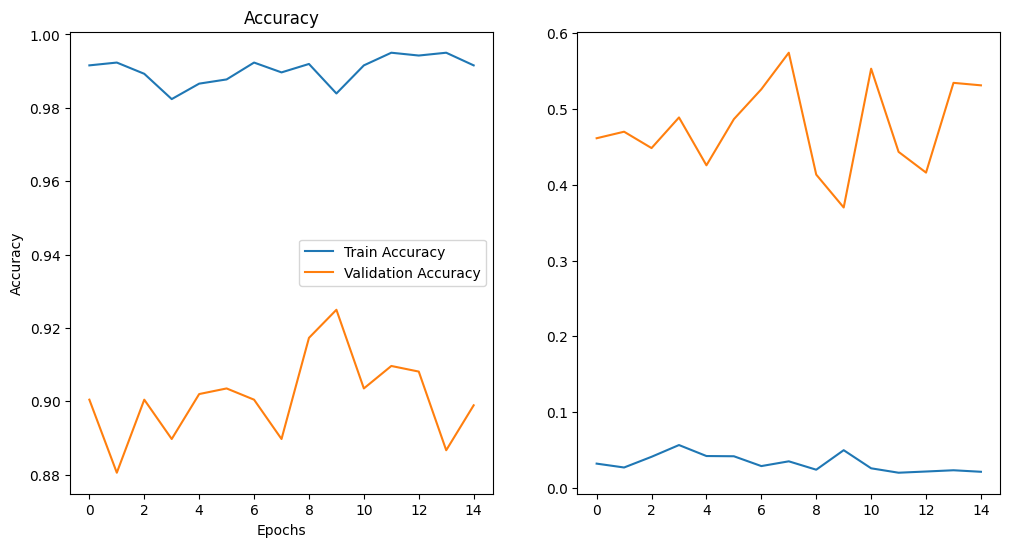

In [93]:
# Vizualizing the model performance

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')

plt.show()

In [94]:
y_pred2 = model_v1.predict(X_test)
y_pred2_class = np.argmax(y_pred2, axis=1)
print(y_pred2_class)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step
[3 2 0 1 3 1 2 3 1 1 2 0 0 1 1 3 3 2 3 1 3 0 1 1 1 3 2 3 3 1 1 3 0 1 3 2 3
 2 0 2 2 0 3 1 1 3 0 3 3 1 2 0 3 3 1 3 0 3 1 0 1 1 1 0 3 3 3 0 3 0 0 0 3 1
 0 2 0 2 2 1 1 0 3 3 0 0 1 1 2 1 1 3 1 1 0 1 0 2 3 1 3 1 2 2 3 3 3 0 0 2 1
 0 3 0 3 0 3 3 2 1 0 3 3 0 3 3 0 3 3 0 3 1 1 3 2 1 1 3 1 1 1 1 2 0 1 1 0 2
 2 2 3 1 1 3 1 3 1 1 2 1 3 1 1 1 1 0 0 1 0 1 2 3 3 1 1 3 0 0 3 0 3 0 1 0 3
 2 1 1 2 1 2 1 0 2 1 1 1 1 3 2 3 0 3 1 2 3 2 1 3 2 1 1 1 0 0 3 0 0 3 0 2 1
 3 1 3 0 3 3 3 2 0 0 3 0 0 2 3 3 0 0 3 0 1 1 0 0 2 1 0 1 0 0 1 0 0 0 3 1 3
 3 0 3 3 1 0 0 0 1 1 0 0 3 3 3 0 3 1 1 0 1 2 1 3 3 1 1 0 1 1 0 2 1 1 3 3 2
 3 0 0 1 3 3 1 2 3 1 3 3 0 0 3 1 2 3 1 0 3 1 3 3 2 0 0 3 0 1 3 0 3 1 2 3 1
 3 1 1 2 2 0 3 2 1 3 1 0 1 1 1 3 3 2 0 3 0 1 3 3 3 0 3 3 1 3 1 2 2 1 2 0 3
 1 2 1 0 1 3 3 2 0 3 1 1 0 3 1 1 3 1 1 3 1 3 1 2 3 1 3 3 1 1 1 3 1 1 3 3 0
 3 0 3 0 3 2 2 2 1 3 2 1 1 3 1 2 3 3 0 1 0 3 1 1 1 1 0 1 0 3 1 0 0 3 2 0 2
 1 0 0 3 0 3 1 3 1 1 1 1 0 1 0 2 2 3 0 1 0 3 2 0 3 3 0 1 1 

In [95]:
cm = confusion_matrix(y_true_classes, y_pred2_class)
print("Confusion Matric:\n", cm)

Confusion Matric:
 [[146  14   4   4]
 [  4 179   0  17]
 [  3  15  88   3]
 [  0   2   0 174]]


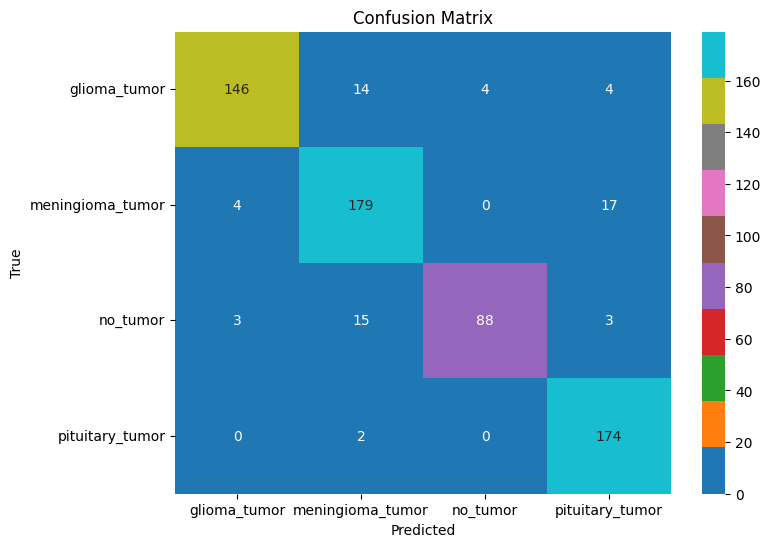

In [96]:
# Confusion Matrix with heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='tab10', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [97]:
print("Classification Report:\n", classification_report(y_true_classes, y_pred_class, target_names=labels))

Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       0.94      0.86      0.90       168
meningioma_tumor       0.82      0.94      0.88       200
        no_tumor       0.97      0.81      0.88       109
 pituitary_tumor       0.96      0.98      0.97       176

        accuracy                           0.91       653
       macro avg       0.92      0.90      0.91       653
    weighted avg       0.91      0.91      0.91       653



(619, 495, 3)


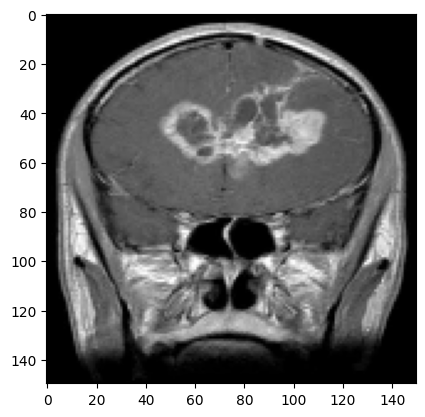

In [98]:
# Reading Image from directory
test_img = cv.imread("E:\\UCT Training AIMLDS\\GENAI_IITG_6Months\\brain_tumor_dataset\\Testing\\glioma_tumor\\image.jpg")
plt.imshow(test_img)
print(test_img.shape)

# Resize image
test_img = cv.resize(test_img,(150,150))
plt.imshow(test_img)
test_input = test_img.reshape(1,150,150,3)


In [99]:
# Predicting the image
pred = model_v1.predict(test_input)
pred_class = np.argmax(pred, axis=1)
print(pred_class)
print(labels[pred_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
[1]
meningioma_tumor


In [101]:
model_v1.save("brain_tumor_classifier_model_v1.h5")

In [102]:
# Read the saved model
from tensorflow.keras.models import load_model
saved_model = load_model("brain_tumor_classifier_model_v1.h5")  
saved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,945,734 (26.50 MB)

 Trainable params: 6,944,772 (26.49 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)